# Name That Move — training pipeline

End-to-end example: load data → augment → extract MiniRocket features → train.

Loading 'all_10_motif': 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 151/151 [00:00<00:00, 21314.53file/s]


Dataset ready — X: (5784, 6, 96), y: (5784,)
Features extracted — shape: (5784, 9996, 1)


LR finder suggested: 6.31e-05


epoch,train_loss,valid_loss,accuracy,time
0,2.181024,2.047458,0.572169,00:00
1,1.871004,1.631234,0.634399,00:00
2,1.503178,1.220699,0.729473,00:00
3,1.149208,0.912446,0.785653,00:00
4,0.873442,0.702461,0.815039,00:00
5,0.679439,0.565380,0.846154,00:00
6,0.529546,0.466704,0.880726,00:00
7,0.421086,0.403122,0.891098,00:00
8,0.352101,0.354585,0.904927,00:00
9,0.289996,0.308170,0.917891,00:00


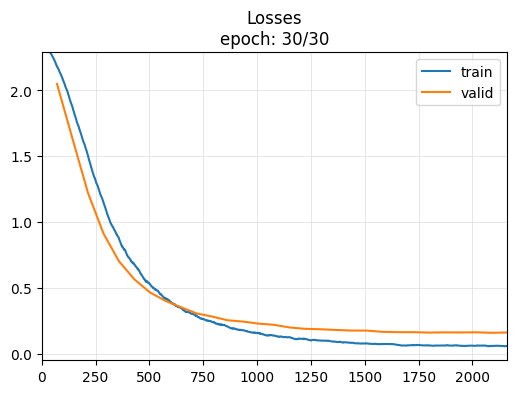

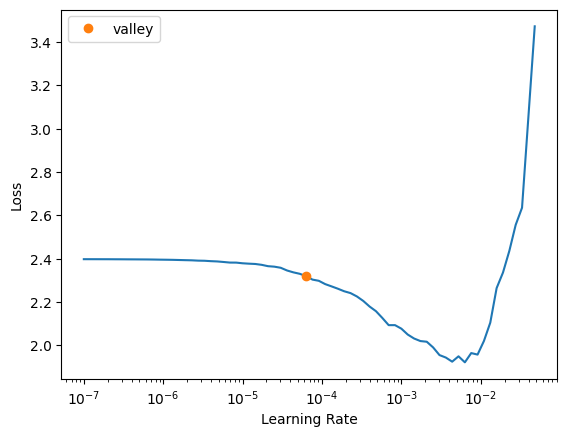

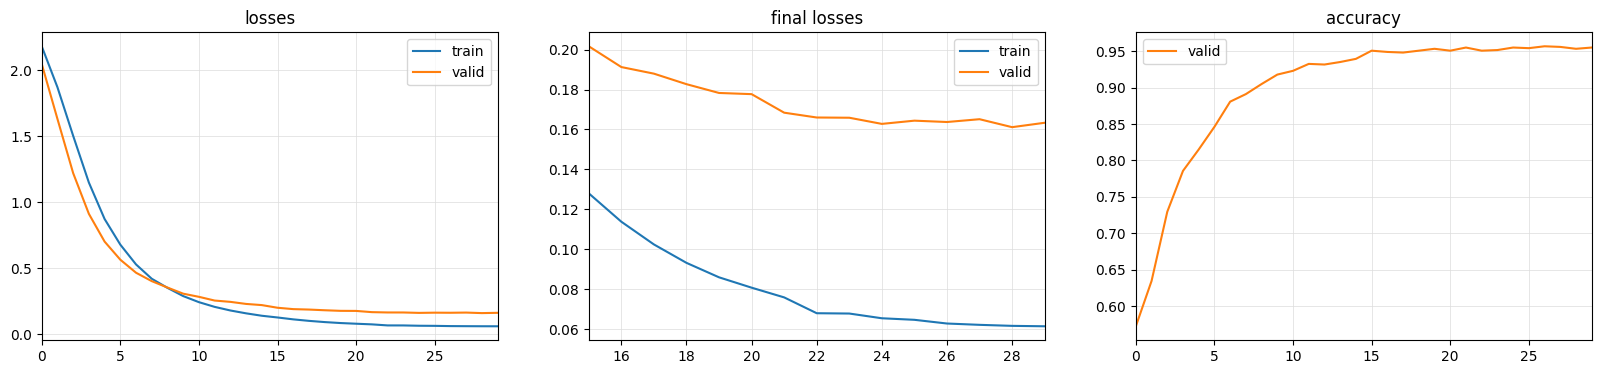

Total time              : 25.709799
Artifacts saved to 'models/' with tag '20251023RoseMJDasha'


In [1]:
from name_that_move import extract_features, make_dataset, save_artifacts, train

BASE_PATH = '../data/motion-11-RoseMJDasha-Meany'  # adjust to your data root
TAG       = '20251023RoseMJDasha'

# 1. Load + augment + split
X, y, splits = make_dataset(
    base_path=BASE_PATH,
    n_aug=2,
    val_fraction=0.2,
    random_seed=42,
)

# 2. Fit MiniRocket and extract features
X_feat, mrf = extract_features(X, splits)

# 3. Train linear head (lr=None → auto LR finder)
learn = train(X_feat, y, splits, epochs=30, lr=None)

# 4. Save artefacts
save_artifacts(mrf, learn, X, output_dir='./models', tag=TAG)